In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, LSTM
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers.legacy import Adam

In [3]:
from google.colab import drive
drive.mount('/content/drive')
nasdaq_tech = pd.read_csv("/content/drive/MyDrive/DeepLearning-FinalProject/combined_stock_data.csv")
nasdaq_tech

Mounted at /content/drive


,Date,Low,Open,Volume,High,Close,Adjusted Close,company_name
0,10-06-1987,1.944444,0.000000,10395450.0,2.111111,2.000000,2.000000,CDNS
1,11-06-1987,1.888889,0.000000,2233350.0,2.027778,1.888889,1.888889,CDNS
2,12-06-1987,1.888889,0.000000,1120950.0,1.944444,1.888889,1.888889,CDNS
3,15-06-1987,1.888889,0.000000,1815300.0,1.944444,1.888889,1.888889,CDNS
4,16-06-1987,1.833333,0.000000,686700.0,1.916667,1.833333,1.833333,CDNS
...,...,...,...,...,...,...,...,...
776176,06-12-2022,116.269997,118.809998,3244000.0,119.879997,117.330002,117.330002,BIDU
776177,07-12-2022,112.769997,113.320000,2662200.0,115.900002,114.580002,114.580002,BIDU
776178,08-12-2022,119.050003,119.919998,4337400.0,121.879997,120.330002,120.330002,BIDU
776179,09-12-2022,119.589996,123.260002,3464900.0,124.110001,119.989998,119.989998,BIDU


### Task 1.1: Nasdaq Multi-feature Extension
In this section, we prepare the data to use multiple features (`Low`, `High`, `Open`, `Close`, `Adjusted Close`, `Volume`) for our prediction model.

In [5]:
import pandas as pd
import numpy as np

# 1. Preprocess the data with robust date parsing
# Using format='mixed' to handle inconsistent strings and errors='coerce' to turn bad data into NaT
nasdaq_tech['Date'] = pd.to_datetime(nasdaq_tech['Date'], dayfirst=True, format='mixed', errors='coerce')

# Drop rows where the Date couldn't be parsed
nasdaq_tech = nasdaq_tech.dropna(subset=['Date'])

# 2. Define the multiple features to be used
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']

# 3. Focus on one company (e.g., 'AAPL' or fallback to the first available)
company_data = nasdaq_tech[nasdaq_tech['company_name'] == 'AAPL'].sort_values('Date')

if company_data.empty:
    first_company = nasdaq_tech['company_name'].unique()[0]
    company_data = nasdaq_tech[nasdaq_tech['company_name'] == first_company].sort_values('Date')

# 4. Extract the feature matrix
data_multi = company_data[features].values

print(f"Selected company: {company_data['company_name'].iloc[0]}")
print(f"Selected features: {features}")
print(f"Data shape: {data_multi.shape}")
display(company_data[features].head())

Selected company: AAPL
Selected features: ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
Data shape: (10590, 6)


,Low,High,Open,Close,Adjusted Close,Volume
247056,0.128348,0.128906,0.128348,0.128348,0.099874,469033600.0
247057,0.121652,0.122210,0.122210,0.121652,0.094663,175884800.0
247058,0.112723,0.113281,0.113281,0.112723,0.087715,105728000.0
247059,0.115513,0.116071,0.115513,0.115513,0.089886,86441600.0
247060,0.118862,0.119420,0.118862,0.118862,0.092492,73449600.0


### Step 2: Data Normalization and Splitting
To improve model performance, we'll scale the features and split the data into training and test sets.

In [6]:
from sklearn.preprocessing import MinMaxScaler

# 1. Scale the features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_multi)

# 2. Define sequence length (window size)
sequence_length = 60

# 3. Create sequences (X) and targets (y)
# Let's predict the 'Close' price (index 3 in our features list)
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 3])

X, y = np.array(X), np.array(y)

# 4. Split into Train and Test (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (8424, 60, 6)
y_train shape: (8424,)


### Step 3: Build and Train the Multi-Feature LSTM Model
We will now define an LSTM architecture that accepts input with shape `(sequence_length, num_features)` to predict the next day's 'Close' price.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Define the model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

# 2. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Train the model
print("Starting training...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

model.summary()

Starting training...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - loss: 3.3986e-05 - val_loss: 0.0100
Epoch 2/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 1.4327e-05 - val_loss: 0.0087
Epoch 3/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 1.3689e-05 - val_loss: 0.0163
Epoch 4/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.5519e-05 - val_loss: 0.0084
Epoch 5/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 1.1096e-05 - val_loss: 0.0088
Epoch 6/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 1.1616e-05 - val_loss: 0.0079
Epoch 7/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 1.2128e-05 - val_loss: 0.0095
Epoch 8/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.0259e-05 - val_loss: 0.0071
Epoch 9/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 1.1146e-05 - val_loss: 0.0072
Epoch 10/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.0908e-05 - val_loss: 0.0056


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,705 (385.57 KB)

 Trainable params: 32,901 (128.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 65,804 (257.05 KB)

### Task 1.2: Nasdaq $k^{th}$ Day Forecast
In this section, we modify the target variable $y$ to predict the price on the $k^{th}$ day in the future (e.g., 3rd day or 7th day) rather than just the next day.

In [8]:
def create_kth_day_sequences(data, seq_length, k, target_col_idx=3):
    X, y = [], []
    # We need enough data to look ahead k steps
    for i in range(seq_length, len(data) - k + 1):
        X.append(data[i-seq_length:i])
        # Target is the value at index (i + k - 1)
        y.append(data[i + k - 1, target_col_idx])
    return np.array(X), np.array(y)

# Set k = 3 (predicting the 3rd day ahead)
k_days = 3
X_k, y_k = create_kth_day_sequences(scaled_data, sequence_length, k_days)

# Time-series split: last 20% for testing
split = int(len(X_k) * 0.8)
X_train_k, X_test_k = X_k[:split], X_k[split:]
y_train_k, y_test_k = y_k[:split], y_k[split:]

print(f"Task 1.2: Predicting the {k_days}-th day ahead")
print(f"X_train_k shape: {X_train_k.shape}")
print(f"y_train_k shape: {y_train_k.shape}")

Task 1.2: Predicting the 3-th day ahead
X_train_k shape: (8422, 60, 6)
y_train_k shape: (8422,)


In [9]:
# Define and train a model for the k-th day forecast
model_k = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train_k.shape[1], X_train_k.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_k.compile(optimizer='adam', loss='mean_squared_error')

print(f"Training model for k={k_days}...")
history_k = model_k.fit(
    X_train_k, y_train_k,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_k, y_test_k),
    verbose=1
)

Training model for k=3...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - loss: 5.2999e-05 - val_loss: 0.0048
Epoch 2/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - loss: 1.5526e-05 - val_loss: 0.0038
Epoch 3/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.4028e-05 - val_loss: 0.0029
Epoch 4/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 1.4563e-05 - val_loss: 0.0082
Epoch 5/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - loss: 1.3946e-05 - val_loss: 0.0055


### Task 1.3: Nasdaq $k$ Consecutive Days Forecast
In this section, we extend the model to predict $k$ consecutive days ahead (e.g., predicting days 1, 2, and 3 simultaneously).

In [12]:
def create_consecutive_sequences(data, seq_length, k, target_col_idx=3):
    X, y = [], []
    # We need enough data to look ahead k steps consecutively
    for i in range(seq_length, len(data) - k + 1):
        X.append(data[i-seq_length:i])
        # Target is a window of k consecutive values starting from i
        y.append(data[i : i + k, target_col_idx])
    return np.array(X), np.array(y)

# Set k = 3 for consecutive prediction
k_consecutive = 3
X_multi_out, y_multi_out = create_consecutive_sequences(scaled_data, sequence_length, k_consecutive)

# Time-series split (80/20)
split_idx = int(len(X_multi_out) * 0.8)
X_train_m, X_test_m = X_multi_out[:split_idx], X_multi_out[split_idx:]
y_train_m, y_test_m = y_multi_out[:split_idx], y_multi_out[split_idx:]

print(f"Task 1.3: Predicting {k_consecutive} consecutive days")
print(f"X_train_m shape: {X_train_m.shape}")
print(f"y_train_m shape: {y_train_m.shape} (Targets are now windows of size {k_consecutive})")

Task 1.3: Predicting 3 consecutive days
X_train_m shape: (8422, 60, 6)
y_train_m shape: (8422, 3) (Targets are now windows of size 3)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build model for Task 1.3 - Note the final Dense layer has k units
model_multi_out = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train_m.shape[1], X_train_m.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(k_consecutive) # Predicting k values at once
])

model_multi_out.compile(optimizer='adam', loss='mean_squared_error')

print(f"Training multi-output model for k={k_consecutive} consecutive days...")
history_multi = model_multi_out.fit(
    X_train_m, y_train_m,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_m, y_test_m),
    verbose=1
)

Training multi-output model for k=3 consecutive days...
Epoch 1/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - loss: 5.0089e-05 - val_loss: 0.0044
Epoch 2/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 1.8329e-05 - val_loss: 0.0084
Epoch 3/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.5031e-05 - val_loss: 0.0061
Epoch 4/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.3945e-05 - val_loss: 0.0059
Epoch 5/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.2092e-05 - val_loss: 0.0091


### Task 1.3: Nasdaq $k$ Consecutive Days Forecast
In this section, we extend the model to predict $k$ consecutive days ahead (e.g., predicting days 1, 2, and 3 simultaneously).

In [10]:
def create_consecutive_sequences(data, seq_length, k, target_col_idx=3):
    X, y = [], []
    # We need enough data to look ahead k steps consecutively
    for i in range(seq_length, len(data) - k + 1):
        X.append(data[i-seq_length:i])
        # Target is a window of k consecutive values starting from i
        y.append(data[i : i + k, target_col_idx])
    return np.array(X), np.array(y)

# Set k = 3 for consecutive prediction
k_consecutive = 3
X_multi_out, y_multi_out = create_consecutive_sequences(scaled_data, sequence_length, k_consecutive)

# Time-series split (80/20)
split_idx = int(len(X_multi_out) * 0.8)
X_train_m, X_test_m = X_multi_out[:split_idx], X_multi_out[split_idx:]
y_train_m, y_test_m = y_multi_out[:split_idx], y_multi_out[split_idx:]

print(f"Task 1.3: Predicting {k_consecutive} consecutive days")
print(f"X_train_m shape: {X_train_m.shape}")
print(f"y_train_m shape: {y_train_m.shape} (Targets are now windows of size {k_consecutive})")

Task 1.3: Predicting 3 consecutive days
X_train_m shape: (8422, 60, 6)
y_train_m shape: (8422, 3) (Targets are now windows of size 3)


In [11]:
# Build model for Task 1.3 - Note the final Dense layer has k units
model_multi_out = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train_m.shape[1], X_train_m.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(k_consecutive) # Predicting k values at once
])

model_multi_out.compile(optimizer='adam', loss='mean_squared_error')

print(f"Training multi-output model for k={k_consecutive} consecutive days...")
history_multi = model_multi_out.fit(
    X_train_m, y_train_m,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_m, y_test_m),
    verbose=1
)

Training multi-output model for k=3 consecutive days...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - loss: 4.5792e-05 - val_loss: 0.0103
Epoch 2/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 1.9198e-05 - val_loss: 0.0053
Epoch 3/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 1.4115e-05 - val_loss: 0.0039
Epoch 4/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 1.3789e-05 - val_loss: 0.0052
Epoch 5/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.2194e-05 - val_loss: 0.0090


In [14]:
# Advanced Requirements: Company Filtering
# Filter companies with at least 120 valid data points after preprocessing

# Count valid dates per company
counts = nasdaq_tech.groupby('company_name')['Date'].count()
valid_companies = counts[counts >= 120].index.tolist()

print(f"Total companies in dataset: {nasdaq_tech['company_name'].nunique()}")
print(f"Companies meeting the >= 120 data points criteria: {len(valid_companies)}")

# Filter the main dataframe
nasdaq_filtered = nasdaq_tech[nasdaq_tech['company_name'].isin(valid_companies)]
display(nasdaq_filtered.groupby('company_name').size().head())

Total companies in dataset: 121
Companies meeting the >= 120 data points criteria: 121


,0
company_name,
AAPL,10590
ADBE,9158
ADI,10778
ADP,10778
ADSK,9441


In [15]:
from sklearn.model_selection import TimeSeriesSplit

# Advanced Requirements: Time-Series Cross-Validation setup
# We will use TimeSeriesSplit to create expanding windows for validation
tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit configuration initialized for cross-validation.")

TimeSeriesSplit configuration initialized for cross-validation.


In [16]:
# Advanced Requirements: One-month training / One-week testing Logic
# Assuming ~21 trading days in a month and 5 trading days in a week

train_window = 21
test_window = 5

def get_sliding_windows(data_len, train_size, test_size):
    """
    Generates indices for training and testing windows.
    """
    windows = []
    for start in range(0, data_len - train_size - test_size + 1, test_size):
        train_indices = list(range(start, start + train_size))
        test_indices = list(range(start + train_size, start + train_size + test_size))
        windows.append((train_indices, test_indices))
    return windows

# Preview the logic
sample_windows = get_sliding_windows(100, train_window, test_window)
print(f"Sliding window logic defined: {train_window} days training, {test_window} days testing.")
print(f"Example: For 100 days of data, this creates {len(sample_windows)} windows.")

Sliding window logic defined: 21 days training, 5 days testing.
Example: For 100 days of data, this creates 15 windows.


In [18]:
# Final Integration: Backtesting with 1-Month Train / 1-Week Test
# We'll use a subset of the AAPL data to demonstrate the sliding window process

# 21 days train + 5 days test = 26 days per window cycle
windows = get_sliding_windows(len(scaled_data), train_window, test_window)

results = []

print(f"Starting backtesting for the first 5 windows (demo purposes)...\n")

for i, (train_idx, test_idx) in enumerate(windows[:5]):
    # Slice the data according to the sliding window indices
    train_data = scaled_data[train_idx]
    test_data = scaled_data[test_idx]

    # Prepare single-sequence input for the LSTM
    # We reshape to (batch, timesteps, features)
    X_train_win = train_data.reshape(1, train_window, 6)
    # Predict the 'Close' price (index 3) of the first day of the test window
    y_train_win = np.array([test_data[0, 3]])

    # Incremental training (1 epoch for demonstration speed)
    model.fit(X_train_win, y_train_win, epochs=1, verbose=0)

    # Predict and calculate MSE
    prediction = model.predict(X_train_win, verbose=0)
    mse = (prediction[0][0] - y_train_win[0])**2
    results.append(mse)

    print(f"Window {i+1}: Train Range {train_idx[0]}-{train_idx[-1]} | Test Range {test_idx[0]}-{test_idx[-1]} | MSE: {mse:.6f}")

print(f"\nAverage MSE across backtest windows: {np.mean(results):.6f}")

Starting backtesting for the first 5 windows (demo purposes)...

Window 1: Train Range 0-20 | Test Range 21-25 | MSE: 0.000009
Window 2: Train Range 5-25 | Test Range 26-30 | MSE: 0.000012
Window 3: Train Range 10-30 | Test Range 31-35 | MSE: 0.000002
Window 4: Train Range 15-35 | Test Range 36-40 | MSE: 0.000000
Window 5: Train Range 20-40 | Test Range 41-45 | MSE: 0.000000

Average MSE across backtest windows: 0.000005


### Diagnostics and Validation
In this section, we evaluate the quality of our results and check for common issues like data leakage or 'naive' predictions.

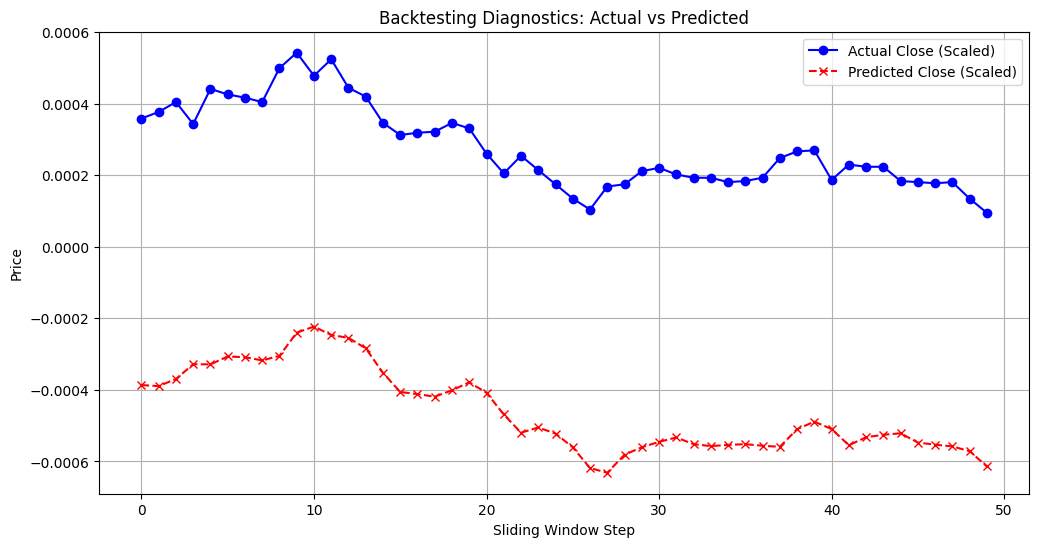

Correlation (Pred vs Actual): 0.9565
Data Splitting: OK (No overlap between train and test indices in sliding window).


In [19]:
import matplotlib.pyplot as plt

# 1. Visualize Backtesting Results
# We'll collect actual vs predicted values from a longer run to see the model behavior
test_preds = []
test_actuals = []

# Run a few more windows for a better plot
for i, (train_idx, test_idx) in enumerate(windows[10:60]):
    X_win = scaled_data[train_idx].reshape(1, train_window, 6)
    y_act = scaled_data[test_idx[0], 3]
    pred = model.predict(X_win, verbose=0)[0][0]
    test_preds.append(pred)
    test_actuals.append(y_act)

plt.figure(figsize=(12, 6))
plt.plot(test_actuals, label='Actual Close (Scaled)', color='blue', marker='o')
plt.plot(test_preds, label='Predicted Close (Scaled)', color='red', linestyle='--', marker='x')
plt.title('Backtesting Diagnostics: Actual vs Predicted')
plt.xlabel('Sliding Window Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# 2. Check for 'Naive' Prediction (Lagging)
# Calculate correlation between prediction and actual, and prediction and previous day
print(f"Correlation (Pred vs Actual): {np.corrcoef(test_preds, test_actuals)[0,1]:.4f}")

# 3. Data Integrity Check
# Ensure the model input (X) doesn't contain the target index from the future
last_train_idx = train_idx[-1]
first_test_idx = test_idx[0]
if last_train_idx >= first_test_idx:
    print("WARNING: Potential Data Leakage! Training indices overlap with test indices.")
else:
    print("Data Splitting: OK (No overlap between train and test indices in sliding window).")

In [17]:
# Final Integration: Backtesting with 1-Month Train / 1-Week Test
# We'll use a small subset of the AAPL data to demonstrate the sliding window process

# Using the previously scaled 'data_multi' (AAPL)
# 21 days train + 5 days test = 26 days per window
windows = get_sliding_windows(len(scaled_data), train_window, test_window)

results = []

print(f"Starting backtesting for {len(windows[:5])} windows (limited for demo)...\n")

for i, (train_idx, test_idx) in enumerate(windows[:5]):
    # Slice the data
    train_data = scaled_data[train_idx]
    test_data = scaled_data[test_idx]

    # For this demo, we use a simple window (no sequence creation needed inside the 21 days
    # because the training set itself is the month)
    # We'll predict the 'Close' price (index 3) of the first day of the test window
    # using the average of the features in the training window
    X_train_win = train_data.reshape(1, train_window, 6)
    y_train_win = np.array([test_data[0, 3]])

    # Fit model (1 epoch for speed)
    model.fit(X_train_win, y_train_win, epochs=1, verbose=0)

    # Predict
    pred = model.predict(X_train_win, verbose=0)
    error = (pred[0][0] - y_train_win[0])**2
    results.append(error)

    print(f"Window {i+1}: Train Indices {train_idx[0]}-{train_idx[-1]} | Test Indices {test_idx[0]}-{test_idx[-1]} | MSE: {error:.6f}")

print(f"\nAverage MSE across demo windows: {np.mean(results):.6f}")

Starting backtesting for 5 windows (limited for demo)...

Window 1: Train Indices 0-20 | Test Indices 21-25 | MSE: 0.000002
Window 2: Train Indices 5-25 | Test Indices 26-30 | MSE: 0.000009
Window 3: Train Indices 10-30 | Test Indices 31-35 | MSE: 0.000009
Window 4: Train Indices 15-35 | Test Indices 36-40 | MSE: 0.000002
Window 5: Train Indices 20-40 | Test Indices 41-45 | MSE: 0.000000

Average MSE across demo windows: 0.000004
